# Task 1: Linear Discriminant Analysis


In [1]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.metrics import confusion_matrix, classification_report, precision_score

def plot_digits(data):
    # Function to visualize the digits from data
    fig, ax = plt.subplots(10, 10, figsize=(8, 8),
                           subplot_kw=dict(xticks=[], yticks=[]))
    fig.subplots_adjust(hspace=0.05, wspace=0.05)
    for i, axi in enumerate(ax.flat):
        im = axi.imshow(data[i].reshape(8, 8), cmap='binary')
        im.set_clim(0, 16)

We load digits datasets. It contains 1797 images, each (64,) shape (8x8).

In [2]:
digits = load_digits()
print(f"Data shape : {digits.data.shape}")
print(f"Target shape : {digits.target.shape}")

Data shape : (1797, 64)
Target shape : (1797,)


### 1.1 Visualize a few digit images from the dataset.

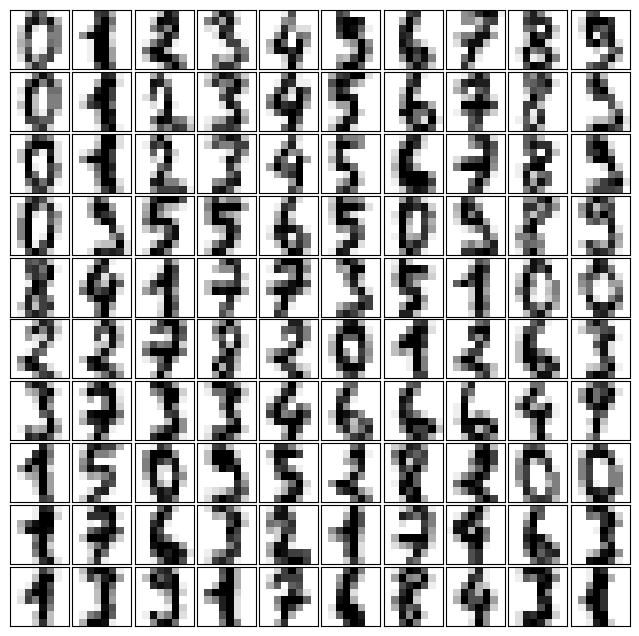

In [3]:
# Write your code here
plot_digits(digits.data)

### 1.2 Split dataset into train and test datasets. Apply PCA.



In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target
    )
classes = [0, 1,2,3,4,5,6,7,8,9]


# Fit scaler and PCA on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit(X_train).transform(X_train)

pca = PCA(n_components=50)
X_train_pca = pca.fit(X_train).transform(X_train)

# Apply the same transformations to test data (very important!)
X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test)

X_train, X_test = X_train_pca, X_test_pca
n_features = X_train.shape[-1]


### 1.3 Compute the mean vector of each class.

Given `X_train` with shape `(n_samples, n_features)` and corresponding class labels `y_train`,  
we can compute the mean feature vector for each class as follows:


In [5]:
g = np.zeros((len(classes), n_features))
for cur_class in classes:
  g[cur_class] = np.mean(X_train[y_train == cur_class], axis=0)

**Visualizing Class Centers**

Visualizing the class mean vectors (`g`) and training samples  
along the first two principal coordinates:


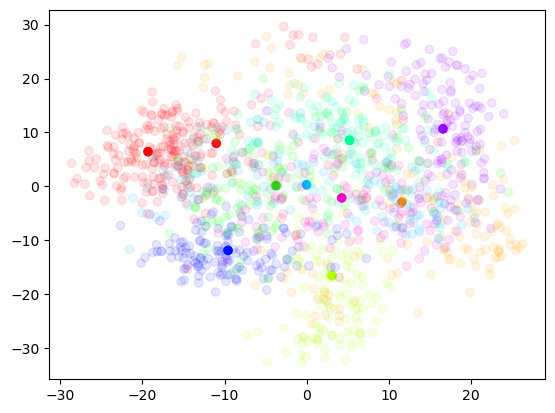

In [6]:
feature_1 = 1
feature_2 = 2
plt.scatter(g[:,feature_1], g[:,feature_2], c=classes,cmap="hsv")
plt.scatter(X_train[:,feature_1], X_train[:,feature_2], c=y_train, alpha=0.1,cmap="hsv")

### 1.4 Formulate and compute the intra-class scatter matrix $S_w$

The matrix $S_w$ measures how spread out the samples are inside each class.

Mathematical formulation:

$$S_w = \sum_k \frac{1}{N_k}A_kA_k^T$$

with $A_k$ the data of class $k$ centered around the mean of the class $k$.

$S_w$ is basically the sum of all covariance $S_k$ of each class $k$.

In [7]:
def compute_A_k(k):
  # Center data of class k around its mean vector g[k]
  cur_class = classes[k]
  A_k = (X_train[y_train == cur_class] - g[cur_class]).T
  assert A_k.shape[0] == n_features
  return A_k

def compute_S_w():
  # Compute S_w: measures how spread out samples are inside each class
  # For each class:
  #   - Center samples (A_k)
  #   - Compute variation (A_k @ A_k.T)
  #   - Normalize by n_k and sum across classes
  S_w = 0
  for k in range(len(classes)):
    cur_class = classes[k]
    A_k = compute_A_k(k)
    n_k = X_train[y_train == cur_class].shape[0]
    S_w += 1 / n_k * A_k @ A_k.T
  assert S_w.shape == (n_features, n_features)
  return S_w

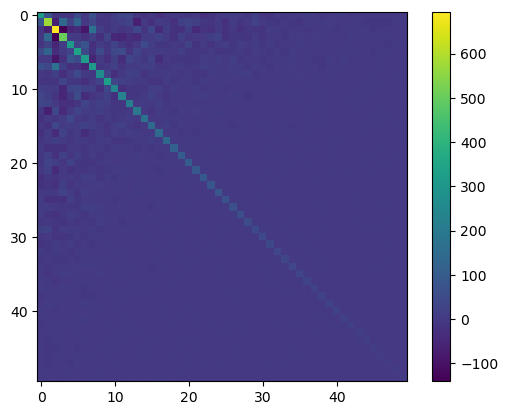

In [8]:
S_w = compute_S_w()
plt.imshow(S_w)
plt.colorbar()

### 1.5 Formulate and compute the inter-class scatter matrix $S_b$

The matrix $S_b$ measures how far apart the **class means** are from the **overall mean**.
It captures the **separation between classes**. Larger $S_b$ means better class separability.

Mathematical formulation:

$$S_b = \frac{1}{M}B B^T$$
with:

- $M$ the number of classes
- $B = \begin{bmatrix} \mu_1 - \mu & \cdots & \mu_M - \mu\end{bmatrix}$ the matrix of means of each class centered around $0$
- $\mu_i$ the mean of the class $i$
- $\mu$ the global mean.

$S_b$ is basically the covariance of the means of each class centered around $0$.

In [9]:
def compute_B():
  # Center class mean vectors around the global mean
  # Returns B with shape (n_features, n_classes)
  g_mean = np.mean(X_train)
  B = (g - g_mean).T
  assert B.shape == (n_features, len(classes))
  return B

def compute_S_b():
  # Compute S_b: measures how far class means are from the global mean
  # Uses B to calculate between-class spread
  B = compute_B()
  S_b = 1 / len(classes) * B @ B.T
  assert S_b.shape == (n_features, n_features)
  return S_b

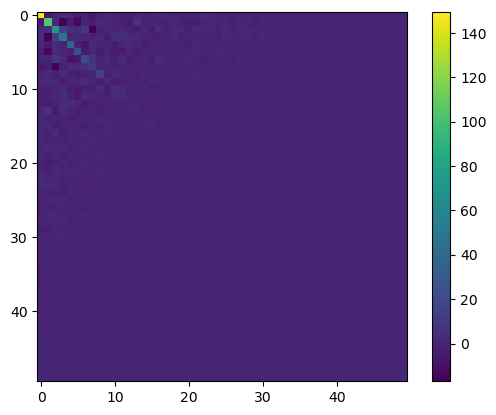

In [10]:
S_b = compute_S_b()
plt.imshow(S_b)
plt.colorbar()

### 1.6 Set up the Fisher Criterion as a generalized eigenvalue problem

To find the optimal projection directions $ a $,  we solve the **Fisher criterion**, expressed as a generalized eigenvalue problem:

$$
S_b\, a = \lambda\, S_w\, a
$$

where:
- $S_b$: between-class scatter matrix  
- $S_w$: within-class scatter matrix  
- $\lambda$: eigenvalue (class separability along direction $a$)  
- $a$: eigenvector (LDA projection direction)


In [11]:
matrix = np.linalg.inv(S_w) @ S_b       # Form matrix S_w^{-1} * S_b  (convert to standard eigenvalue problem)
w, a = np.linalg.eig(matrix)            # Compute eigenvalues (w) and eigenvectors (a)

### 1.7 Sort the eigenvalues/eigenvectors and compare with the results shown in the lecture.

/usr/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


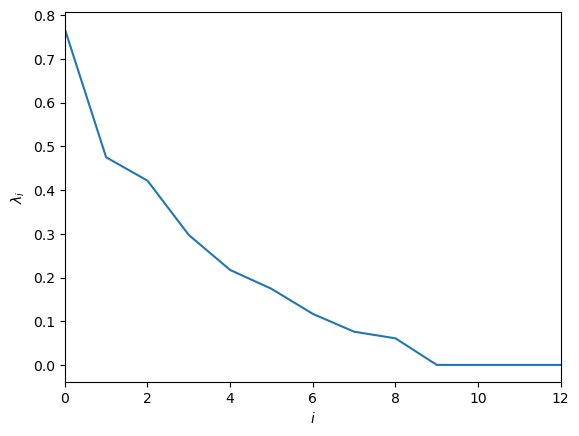

In [12]:
idx = np.argsort(w)[::-1]
w = w[idx]
a = a[idx]
plt.plot(w)
plt.ylabel(r"$\lambda_i$")
plt.xlabel(r"$i$")
plt.xlim(0,12)
plt.show()

### 1.8 Apply the LDA directions to the test data and visualize in 2D.

Visualize test samples in the **2 most discriminative** LDA directions (those with the largest eigenvalues $\lambda$).

In [13]:
idx = np.argsort(w.real)[::-1]          # order eigenpairs by λ (desc)
a_main = a[idx[:2]]# Write your code here         # top-2 LDA directions
X_transformed = X_test @ a_main.T # project test data

/usr/lib/python3.13/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


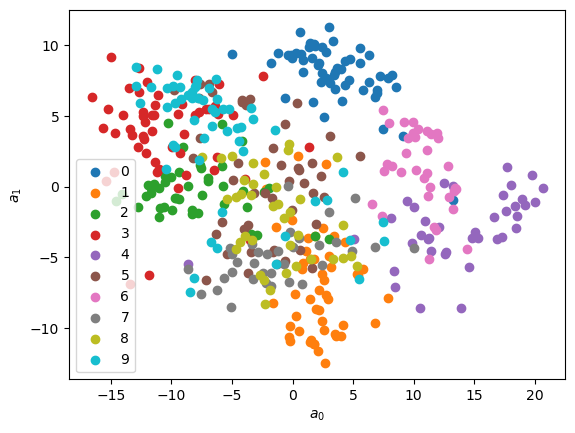

In [14]:
for k, class_ in enumerate(classes):
  plt.scatter(X_transformed[y_test==class_][:, 0], X_transformed[y_test==class_][:, 1], label=class_)
plt.xlabel(r"$a_0$")
plt.ylabel(r"$a_1$")
plt.legend()
plt.show()

### 1.9 Why do we maximize the ratio of between-class to within-class scatter in LDA?

We maximize the ratio of between-class to within-class scatter in LDA because we want to find a projection that discriminate the most our dataset.

This projection is given by the projection that maximise the distance between mean of each class to avoid overlaps on classes.
This is called the between-class or inter-class criteria.

However, if we just consider the distance between means, we can have overlap on classes, even if the means are far away if the variances of classes are high.
So in the same time, we try to minimise variance of theses classes to avoid overlap, and this is called the within-class or intra-class criteria.

So we want to minimise the variance of each class (within-class) and we want to maximise distance between means (between-class).

As we want to minimise variance of each class, we try to maximise inverse of variance.

That's why we want to maximise the ratio of the distance between means to the variance of each class, so the ratio of between-class to within-class.

### 1.10 For 𝑀 classes, how many discriminant directions can LDA provide at most?

For instance, if we have only 1 class, we don't need any discriminant to determine that a new element will be labeled in this class, because it's the unique class.
So we have $1 - 1 = 0$ discriminant needed.

If we have 2 classes, to discriminate the two classes, the projection of the classes on a single line are enough to discriminate the two classes.
In other term, $2 - 1 = 1$ discriminant direction is needed.

That's why in the same way, for $M$ classes, LDA can provide $M - 1$ discriminant directions at most to properly discriminate each class.

### 1.11 What is the key difference between PCA and LDA in terms of the criterion they optimize?

# Task 2: k-means

### 2.1 Create a subset of MNIST which consists of 2000 randomly sampled instances of “3”s and “7”s.

In [15]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

images, images_labels = fetch_openml('mnist_784', return_X_y=True, as_frame=False, parser='auto')
train_images, test_images, train_labels, test_labels = train_test_split(images, images_labels, random_state=42)

def select_with_label(images, labels, desired_labels):
  mask = np.isin(labels, desired_labels)
  return images[mask], labels[mask]

In [16]:
data3, labels3 = select_with_label(images, images_labels, ['3'])
data7, labels7 = select_with_label(images, images_labels, ['7'])
index3 = np.random.choice(np.arange(data3.shape[0]).astype(int), size=1000)
index7 = np.random.choice(np.arange(data7.shape[0]).astype(int), size=1000)
data, labels = np.concatenate([data3[index3], data7[index7]]), np.concatenate([labels3[index3], labels7[index7]])
# data, labels = select_with_label(images, labels, ['3', '7'])

### 2.2 Implement k-means from scratch.

Implement k-means from scratch (do not use 'sklearn') with random initialization of the clusters. Perform the algorithm with $K = 2, 3, \ldots, 10$. Compute objective function $L$ defined earlier for each $K$. Plot $L$ varying with $K$. **Describe** the effect of $K$ over $L$.

*Note: This might take about 2-3 minutes to run an optimized version of K-means for large K.*


In [17]:
import numpy as np

class KMeans:
    def __init__(self, n_clusters, init="random", max_iter=300, seed=None):
        self.n_clusters = int(n_clusters)
        self.init = init
        self.max_iter = int(max_iter)
        self.tol = 1e-4  # stop when centroid movement < tol
        self.centroids = None
        self.seed = seed

    def _init_centroids(self, X):
        n_samples = X.shape[0]
        rng = np.random.default_rng(seed=self.seed)
        if self.init == "random":
            idx = rng.choice(n_samples, size=self.n_clusters, replace=False,)
            return X[idx].copy()

        if self.init == "kmeans++":
          raise NotImplementedError()

        raise ValueError("init must be 'random' or 'kmeans++'")

    def fit(self, X):
        # initialize centroids randomly
        self.centroids = self._init_centroids(X)
        # this function should update self.centroids coordinates
        # for given X
        moves = np.full(self.centroids.shape[1], np.inf)
        while np.max(moves) > self.tol:
            distances = np.array([np.linalg.norm(X - mu, axis=1) for mu in self.centroids])
            # distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            index = np.argmin(distances, axis=1)
            classes = np.zeros((X.shape[0], X.shape[1] - 1))
            classes[np.arange(classes.shape[0]), index] = 1
            print(classes.shape)
            print(X.shape)
            old_centroids = self.centroids.copy()
            self.centroids = np.array([np.mean(X[classes[:, i] == 1], axis=0) for i in range(classes.shape[1])])
            moves = np.linalg.norm(self.centroids - old_centroids, axis=1)
        raise NotImplementedError()

    def predict(self, X):
        # this function for each X returns the cluster
        # it belongs to
        distances = np.array([np.linalg.norm(X - mu, axis=1) for mu in self.centroids])
        return np.argmin(distances, axis=1)
        raise NotImplementedError()

    def fit_predict(self, X, y=None):
        return self.fit(X).labels_

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import tqdm

Ks = range(2, 11)
L_values = []

for K in tqdm.tqdm(Ks):
    model = KMeans(n_clusters=K, init="random", max_iter=300)
    model.fit(data)

    # compute the objective function L
    labels = model.labels_
    centroids = model.centroids
    L = np.linalg.norm(data - centroids[labels])
    L_values.append(L)

plt.plot(Ks, L_values, marker="o")
plt.xlabel("$K$")
plt.ylabel("$L$")
plt.title("K-means objective $L$ vs. number of clusters $K$")
plt.show()


  0%|          | 0/9 [00:00<?, ?it/s]

IndexError: shape mismatch: indexing arrays could not be broadcast together with shapes (2000,) (2,) 

### 2.3 k++ initialization

Implement k++ assignment explained in the lecture. Compare the objective function values of several runs with the random and k++ initialization for $K=2$.

In [ ]:
# Write your code here
# Use np.random.choice with p=distance^2

### (extra) Artificial example for K-means++

If you want to **see the difference** between random and k-means++ initialization more clearly, you can run this *artificial example*.

To make your results **reproducible**, update your `KMeans` class so that it accepts a `seed` argument and uses it in the random number generator:

```python
rng = np.random.default_rng(self.seed)
```

You might need to play with seed parameter to get different results for k-means++ and random initializations.


In [ ]:
# --- Generate 4 distinct blobs in 2D ---
np.random.seed(42)
centers = np.array([[0, 0], [10, 5], [0, 5], [10, 0]])
X_synth = np.vstack([
    np.random.randn(100, 2) * 0.4 + center for center in centers
])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, init in zip(axes, ["random", "kmeans++"]):
    model = KMeans(n_clusters=2, init=init, max_iter=100, seed=47)
    model.fit(X_synth)
    labels = model.labels_
    ax.scatter(X_synth[:, 0], X_synth[:, 1], c=labels, cmap="tab10", alpha=0.6)
    ax.scatter(model.centroids[:, 0], model.centroids[:, 1], c="red", s=100, marker="x")
    ax.set_title(f"{init} init")

plt.show()

runs = 10
L_random, L_kpp = [], []

for init in ["random", "kmeans++"]:
    for _ in range(runs):
        model = KMeans(n_clusters=4, init=init, max_iter=100)
        model.fit(X_synth)
        L = # Write your code here
        if init == "random":
            L_random.append(L)
        else:
            L_kpp.append(L)

# --- Compare objective values ---
print(f"Random init: mean L = {np.mean(L_random):.2f}, std = {np.std(L_random):.2f}")
print(f"K-means++ init: mean L = {np.mean(L_kpp):.2f}, std = {np.std(L_kpp):.2f}")


# Task 3: GMMs

### 3.1 GMM implementation.

Use a subset of MNIST consisting of 2000 randomly sampled instances of “3”s and “7”s from the previous task. Apply PCA to reduce dimensionality. Implement GMM model from scratch (do not use \sklearn) with random initialization of the parameters.


In [ ]:
class GMM:
    def __init__(self, n_components, max_iter=100, tol=1e-3, reg_covar=1e-6, seed=None):
        self.n_components = int(n_components)
        self.max_iter = int(max_iter)
        self.tol = float(tol)            # stop when llh improvement < tol
        self.reg_covar = float(reg_covar)
        self.seed = seed

        # learned params
        self.pi_ = None                  # mixing weights (K,)
        self.means_ = None               # means (K, D)
        self.covariances_ = None         # covariances (K, D, D)
        self.resp_ = None                # responsibilities (N, K)
        self.n_iter_ = 0
        self.lower_bound_ = -np.inf


    def fit_predict(self, X, y=None):
        #this function returns a cluster number to each element of X
        raise NotImplementedError()


Apply PCA.

In [ ]:
# Write your code here (scaling)

pca = PCA(n_components=10)
data_pca = # Write your code here

In [ ]:
gmm = GMM(n_components=5, max_iter=6000)
predicted_labels = gmm.fit_predict(data_pca)


**Aligning GMM clusters with true labels**

GMM is **unsupervised**, so it only assigns points to clusters (e.g., 0 or 1). It doesn’t know which cluster corresponds to which true class (e.g., 3 or 7).

To make the results comparable with the true labels, we find which class appears most often in each cluster (the **majority class**) and use that mapping when building the confusion matrix below.


In [ ]:
from collections import Counter
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def build_confusion_matrix(labels, predicted_labels, verbose=True):
  class_mapping = {}
  for k in np.unique(predicted_labels):
      maj = Counter(labels[predicted_labels == k]).most_common(1)[0][0]
      class_mapping[k] = maj
      print(f"Cluster {k} → true class {maj}")

  mapped_labels = np.vectorize(class_mapping.get)(predicted_labels)
  cm = confusion_matrix(labels, mapped_labels)
  return cm

cm = build_confusion_matrix(labels, predicted_labels)
ConfusionMatrixDisplay(cm).plot()



### 3.2 Objection function as a function of K.

Perform the algorithm with K = 2, 3, ... , 10 and plot the corresponding objection function $\mathbb{L}$. Explain what you observe.

In [ ]:
# Write your code here

### 3.3 Build confusion matrices using sklearn for kmeans and GMM for K=2 (both with PCA). Describe the results.  

In [ ]:
# Write your code here




### 3.4 Describe the differences between kmeans and GMM (deterministic/probabilistic, parameters, functions to optimize, updates)

# Your answer